# Statistical values distribution - Subcortical Volume

In [1]:
from IPython.display import display, Image

STATIC_RENDERING = True


# This is a static rendering of the notebook.
def show_figure(fig):
    if STATIC_RENDERING:
        img = fig.to_image(format="png")
        display(Image(img))
    else:
        fig.show()


In [2]:
# Comment out the following line to run the notebook in CPU mode
%load_ext cudf.pandas
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import plotly

# Suppress warnings
import warnings

warnings.filterwarnings("ignore")

regions = [
    "Left-Thalamus",
    "Left-Caudate",
    "Left-Putamen",
    "Left-Pallidum",
    "Left-Hippocampus",
    "Left-Amygdala",
    "Left-Accumbens-area",
    "Right-Thalamus",
    "Right-Caudate",
    "Right-Putamen",
    "Right-Pallidum",
    "Right-Hippocampus",
    "Right-Amygdala",
    "Right-Accumbens-area",
]

red = plotly.colors.qualitative.Set1[0]
ieee_marker = dict(color=red, symbol="diamond", size=10)
violin_width = 0.85
violin_jitter = 0.85


In [3]:
def get_pcorr_baseline():
    baseline_subcortical_volume = pd.read_parquet(
        "partial_correlation/partial_correlation_baseline_subcortical_volume.parquet"
    )
    baseline_subcortical_volume["significant"] = (
        baseline_subcortical_volume["p-val"] < 0.05
    )
    baseline_subcortical_volume_avg = (
        baseline_subcortical_volume.groupby("region")
        .agg({"r": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv(
        "partial_correlation_ieee/partial_correlation_baseline_subcortical_volume.csv"
    )

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter out the regions that are not in the data
    baseline_subcortical_volume = baseline_subcortical_volume[
        baseline_subcortical_volume["region"].isin(regions)
    ]
    baseline_subcortical_volume_avg = baseline_subcortical_volume_avg[
        baseline_subcortical_volume_avg["region"].isin(regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(regions)]

    # Create a position mapping dictionary
    region_to_position = {region: i for i, region in enumerate(regions)}

    # Add position columns to each dataframe
    baseline_subcortical_volume["position"] = baseline_subcortical_volume["region"].map(
        region_to_position
    )
    baseline_subcortical_volume_avg["position"] = baseline_subcortical_volume_avg[
        "region"
    ].map(region_to_position)
    ieee_data["position"] = ieee_data["region"].map(region_to_position)

    # Sort by position to ensure correct order
    baseline_subcortical_volume.sort_values(by="position", inplace=True)
    baseline_subcortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "baseline_subcortical_volume": baseline_subcortical_volume,
        "baseline_subcortical_volume_avg": baseline_subcortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_pcorr_baseline_trace(fig, data):
    row, col = 1, 1

    baseline_subcortical_volume = data["baseline_subcortical_volume"]
    baseline_subcortical_volume_avg = data["baseline_subcortical_volume_avg"]
    ieee_data = data["ieee_data"]

    # Use the position columns for x-axis placement
    bar_offset = -0.2  # Shift bars left
    violin_offset = 0.2  # Shift violins right

    blue = px.colors.qualitative.Plotly[4]
    green = px.colors.qualitative.D3[3]

    # Create a bar chart with offset x positions
    bar = go.Bar(
        x=baseline_subcortical_volume_avg["position"] + bar_offset,
        y=baseline_subcortical_volume_avg["significant"],
        name="Ratio",
        marker=dict(color=blue),
        showlegend=True,
        width=0.25,
        yaxis="y",
        customdata=baseline_subcortical_volume_avg["region"],
        hovertemplate="Region: %{customdata}<br>Significant Ratio: %{y:.2f}<extra></extra>",
    )

    violin = go.Violin(
        x=baseline_subcortical_volume["region"],
        y=baseline_subcortical_volume["r"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        meanline_visible=True,
        fillcolor="gray",
        opacity=0.6,
        width=violin_width,
        jitter=violin_jitter,
        showlegend=False,
        name="r coefficient",
        spanmode="hard",
        # side='positive',
        points="all",
        pointpos=0,
        marker=dict(color="orange", opacity=1),
        customdata=baseline_subcortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
    )

    ieee = go.Scatter(
        x=ieee_data["region"],
        y=ieee_data["r"],
        mode="markers",
        yaxis="y2",
        marker=ieee_marker,
        showlegend=True,
        name="IEEE",
        customdata=ieee_data["region"],
        hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
    )

    # fig.add_trace(bar, row=row, col=col, secondary_y=False)
    fig.add_trace(ieee, row=row, col=col)
    fig.add_trace(violin, row=row, col=col)

In [4]:
def get_pcorr_long():
    longitudinal_subcortical_volume = pd.read_parquet(
        "partial_correlation/partial_correlation_longitudinal_subcortical_volume.parquet"
    )
    longitudinal_subcortical_volume["significant"] = (
        longitudinal_subcortical_volume["p-val"] < 0.05
    )
    longitudinal_subcortical_volume_avg = (
        longitudinal_subcortical_volume.groupby("region")
        .agg({"r": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv(
        "partial_correlation_ieee/partial_correlation_longitudinal_subcortical_volume.csv"
    )

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter out the regions that are not in the data
    longitudinal_subcortical_volume = longitudinal_subcortical_volume[
        longitudinal_subcortical_volume["region"].isin(regions)
    ]
    longitudinal_subcortical_volume_avg = longitudinal_subcortical_volume_avg[
        longitudinal_subcortical_volume_avg["region"].isin(regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(regions)]

    # Create a position mapping dictionary
    region_to_position = {region: i for i, region in enumerate(regions)}

    # Add position columns to each dataframe
    longitudinal_subcortical_volume["position"] = longitudinal_subcortical_volume[
        "region"
    ].map(region_to_position)
    longitudinal_subcortical_volume_avg["position"] = (
        longitudinal_subcortical_volume_avg["region"].map(region_to_position)
    )
    ieee_data["position"] = ieee_data["region"].map(region_to_position)

    # Sort by position to ensure correct order
    longitudinal_subcortical_volume.sort_values(by="position", inplace=True)
    longitudinal_subcortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "longitudinal_subcortical_volume": longitudinal_subcortical_volume,
        "longitudinal_subcortical_volume_avg": longitudinal_subcortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_pcorr_longitudinal_trace(fig, data):
    row, col = 1, 2

    longitudinal_subcortical_volume = data["longitudinal_subcortical_volume"]
    longitudinal_subcortical_volume_avg = data["longitudinal_subcortical_volume_avg"]
    ieee_data = data["ieee_data"]

    # Use the position columns for x-axis placement
    bar_offset = -0.2  # Shift bars left
    violin_offset = 0.2  # Shift violins right

    blue = px.colors.qualitative.Plotly[4]
    green = px.colors.qualitative.D3[3]

    # Create a bar chart with offset x positions
    bar = go.Bar(
        x=longitudinal_subcortical_volume_avg["position"] + bar_offset,
        y=longitudinal_subcortical_volume_avg["significant"],
        name="Ratio",
        marker=dict(color=blue),
        showlegend=False,
        width=0.25,
        yaxis="y",
        customdata=longitudinal_subcortical_volume_avg["region"],
        hovertemplate="Region: %{customdata}<br>Significant Ratio: %{y:.2f}<extra></extra>",
    )

    violin = go.Violin(
        x=longitudinal_subcortical_volume["region"],
        y=longitudinal_subcortical_volume["r"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        meanline_visible=True,
        fillcolor="gray",
        opacity=0.6,
        width=violin_width,
        jitter=violin_jitter,
        showlegend=False,
        spanmode="hard",
        name="r coefficient",
        points="all",
        # side='positive',
        marker=dict(color="orange", opacity=1),
        pointpos=0,
        customdata=longitudinal_subcortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
    )

    ieee = go.Scatter(
        x=ieee_data["region"],
        y=ieee_data["r"],
        mode="markers",
        yaxis="y2",
        marker=ieee_marker,
        showlegend=False,
        name="IEEE",
        customdata=ieee_data["region"],
        hovertemplate="Region: %{customdata}<br>r: %{y:.3f}<extra></extra>",
    )

    # fig.add_trace(bar, row=row, col=col, secondary_y=False)
    fig.add_trace(ieee, row=row, col=col)
    fig.add_trace(violin, row=row, col=col)


In [5]:
def get_ancova_baseline():
    baseline_subcortical_volume = pd.read_parquet(
        "ancova/ancova_baseline_subcortical_volume.parquet"
    )
    baseline_subcortical_volume["significant"] = (
        baseline_subcortical_volume["p-unc"] < 0.05
    )
    baseline_subcortical_volume_avg = (
        baseline_subcortical_volume.groupby("region")
        .agg({"F": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv("ancova_ieee/ancova_baseline_subcortical_volume.csv")

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter out the regions that are not in the data
    baseline_subcortical_volume = baseline_subcortical_volume[
        baseline_subcortical_volume["region"].isin(regions)
    ]
    baseline_subcortical_volume_avg = baseline_subcortical_volume_avg[
        baseline_subcortical_volume_avg["region"].isin(regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(regions)]

    # Create a position mapping dictionary
    region_to_position = {region: i for i, region in enumerate(regions)}

    # Add position columns to each dataframe
    baseline_subcortical_volume["position"] = baseline_subcortical_volume["region"].map(
        region_to_position
    )
    baseline_subcortical_volume_avg["position"] = baseline_subcortical_volume_avg[
        "region"
    ].map(region_to_position)
    ieee_data["position"] = ieee_data["region"].map(region_to_position)

    # Sort by position to ensure correct order
    baseline_subcortical_volume.sort_values(by="position", inplace=True)
    baseline_subcortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "baseline_subcortical_volume": baseline_subcortical_volume,
        "baseline_subcortical_volume_avg": baseline_subcortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_ancova_baseline_trace(fig, data):
    row, col = 2, 1

    baseline_subcortical_volume = data["baseline_subcortical_volume"]
    baseline_subcortical_volume_avg = data["baseline_subcortical_volume_avg"]
    ieee_data = data["ieee_data"]

    # Use the position columns for x-axis placement
    bar_offset = -0.2  # Shift bars left
    violin_offset = 0.2  # Shift violins right

    blue = px.colors.qualitative.Plotly[4]
    green = px.colors.qualitative.D3[2]

    # Create a bar chart with offset x positions
    bar = go.Bar(
        x=baseline_subcortical_volume_avg["position"] + bar_offset,
        y=baseline_subcortical_volume_avg["significant"],
        name="Ratio",
        marker=dict(color=blue),
        showlegend=False,
        width=0.25,
        yaxis="y",
        customdata=baseline_subcortical_volume_avg["region"],
        hovertemplate="Region: %{customdata}<br>Significant Ratio: %{y:.2f}<extra></extra>",
    )

    violin = go.Violin(
        x=baseline_subcortical_volume["region"],
        y=baseline_subcortical_volume["F"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        meanline_visible=True,
        fillcolor="gray",
        opacity=0.6,
        width=violin_width,
        jitter=violin_jitter,
        showlegend=False,
        marker=dict(color="orange", opacity=1),
        pointpos=0,
        name="F-value",
        spanmode="hard",
        # side='positive',
        points="all",
        customdata=baseline_subcortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
    )

    ieee = go.Scatter(
        x=ieee_data["region"],
        y=ieee_data["F"],
        mode="markers",
        yaxis="y2",
        marker=ieee_marker,
        showlegend=False,
        name="IEEE",
        customdata=ieee_data["region"],
        hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
    )

    # fig.add_trace(bar, row=row, col=col, secondary_y=False)
    fig.add_trace(ieee, row=row, col=col)
    fig.add_trace(violin, row=row, col=col)

In [6]:
def get_ancova_long():
    longitudinal_subcortical_volume = pd.read_parquet(
        "ancova/ancova_longitudinal_subcortical_volume.parquet"
    )
    longitudinal_subcortical_volume["significant"] = (
        longitudinal_subcortical_volume["p-unc"] < 0.05
    )
    longitudinal_subcortical_volume_avg = (
        longitudinal_subcortical_volume.groupby("region")
        .agg({"F": "mean", "significant": "mean"})
        .reset_index()
    )

    ieee_data = pd.read_csv("ancova_ieee/ancova_longitudinal_subcortical_volume.csv")

    ieee_data.sort_values(by=["region"], inplace=True)
    ieee_data["fs_version"] = "IEEE"

    # Filter out the regions that are not in the data
    longitudinal_subcortical_volume = longitudinal_subcortical_volume[
        longitudinal_subcortical_volume["region"].isin(regions)
    ]
    longitudinal_subcortical_volume_avg = longitudinal_subcortical_volume_avg[
        longitudinal_subcortical_volume_avg["region"].isin(regions)
    ]
    ieee_data = ieee_data[ieee_data["region"].isin(regions)]

    # Create a position mapping dictionary
    region_to_position = {region: i for i, region in enumerate(regions)}

    # Add position columns to each dataframe
    longitudinal_subcortical_volume["position"] = longitudinal_subcortical_volume[
        "region"
    ].map(region_to_position)
    longitudinal_subcortical_volume_avg["position"] = (
        longitudinal_subcortical_volume_avg["region"].map(region_to_position)
    )
    ieee_data["position"] = ieee_data["region"].map(region_to_position)

    # Sort by position to ensure correct order
    longitudinal_subcortical_volume.sort_values(by="position", inplace=True)
    longitudinal_subcortical_volume_avg.sort_values(by="position", inplace=True)
    ieee_data.sort_values(by="position", inplace=True)

    return {
        "longitudinal_subcortical_volume": longitudinal_subcortical_volume,
        "longitudinal_subcortical_volume_avg": longitudinal_subcortical_volume_avg,
        "ieee_data": ieee_data,
    }


def add_ancova_longitudinal_trace(fig, data):
    row, col = 2, 2

    longitudinal_subcortical_volume = data["longitudinal_subcortical_volume"]
    longitudinal_subcortical_volume_avg = data["longitudinal_subcortical_volume_avg"]
    ieee_data = data["ieee_data"]

    # Use the position columns for x-axis placement
    bar_offset = -0.2  # Shift bars left
    violin_offset = 0.2  # Shift violins right

    blue = px.colors.qualitative.Plotly[4]
    green = px.colors.qualitative.D3[2]

    # Create a bar chart with offset x positions
    bar = go.Bar(
        x=longitudinal_subcortical_volume_avg["position"] + bar_offset,
        y=longitudinal_subcortical_volume_avg["significant"],
        name="Ratio",
        marker=dict(color=blue),
        showlegend=False,
        width=0.25,
        yaxis="y",
        customdata=longitudinal_subcortical_volume_avg["region"],
        hovertemplate="Region: %{customdata}<br>Significant Ratio: %{y:.2f}<extra></extra>",
    )

    violin = go.Violin(
        x=longitudinal_subcortical_volume["region"],
        y=longitudinal_subcortical_volume["F"],
        yaxis="y2",
        box_visible=False,
        line_color="DarkSlateGrey",
        fillcolor="gray",
        meanline_visible=False,
        pointpos=0,
        marker=dict(
            color="orange",
            opacity=1,
        ),
        width=violin_width,
        jitter=violin_jitter,
        opacity=0.6,
        showlegend=False,
        name="F-value",
        points="all",
        spanmode="hard",
        customdata=longitudinal_subcortical_volume["region"],
        hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
    )

    ieee = go.Scatter(
        x=ieee_data["region"],
        y=ieee_data["F"],
        mode="markers",
        yaxis="y2",
        marker=ieee_marker,
        showlegend=False,
        name="IEEE",
        customdata=ieee_data["region"],
        hovertemplate="Region: %{customdata}<br>F: %{y:.3f}<extra></extra>",
    )

    # fig.add_trace(bar, row=row, col=col, secondary_y=False)
    fig.add_trace(ieee, row=row, col=col)
    fig.add_trace(violin, row=row, col=col)


## Consistency of Statistically Significant Regions

This analysis quantifies the consistency of statistically significant findings across different brain regions. For each region, we compute the proportion of statistical tests that yield significant results relative to the total number of tests performed. 

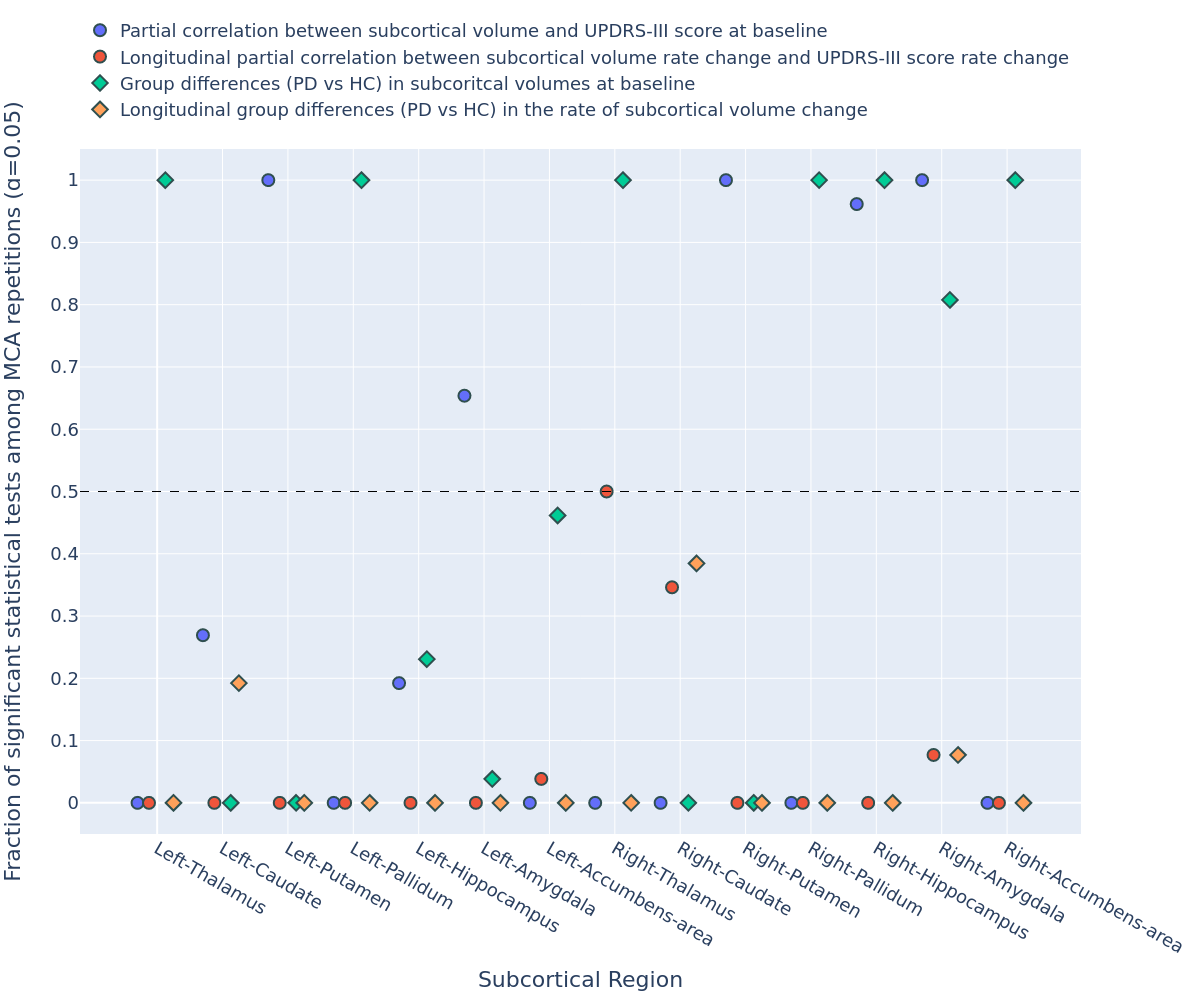

In [7]:
pcorr_baseline_subcortical_volume_avg = get_pcorr_baseline()[
    "baseline_subcortical_volume_avg"
]
pcorr_longitudinal_subcortical_volume_avg = get_pcorr_long()[
    "longitudinal_subcortical_volume_avg"
]
ancova_baseline_subcortical_volume_avg = get_ancova_baseline()[
    "baseline_subcortical_volume_avg"
]
ancova_longitudinal_subcortical_volume_avg = get_ancova_long()[
    "longitudinal_subcortical_volume_avg"
]

fig = go.Figure()

colormap = px.colors.qualitative.Plotly
marker_size = 12
symbol_pcorr = "circle"
symbol_ancova = "diamond"
marker_line = dict(width=2, color="DarkSlateGrey")


def get_jittered_positions(length, jitter_amount):
    # Generate random jitter for x-axis positions
    # jit = np.random.uniform(-jitter_amount, jitter_amount, length)
    return [x + jitter_amount for x in range(length)]


# Create the scatter plot with jitter
pcorr_base = go.Scatter(
    x=get_jittered_positions(
        pcorr_baseline_subcortical_volume_avg["region"].shape[0], -0.3
    ),
    y=pcorr_baseline_subcortical_volume_avg["significant"],
    mode="markers",
    marker=dict(
        color=colormap[0], size=marker_size, symbol=symbol_pcorr, line=marker_line
    ),
    name="Partial correlation between subcortical volume and UPDRS-III score at baseline",
    text=pcorr_baseline_subcortical_volume_avg[
        "region"
    ],  # Store original region names as hover text
)

pcorr_long = go.Scatter(
    x=get_jittered_positions(
        pcorr_longitudinal_subcortical_volume_avg["region"].shape[0], -0.125
    ),
    y=pcorr_longitudinal_subcortical_volume_avg["significant"],
    mode="markers",
    marker=dict(
        color=colormap[1], size=marker_size, symbol=symbol_pcorr, line=marker_line
    ),
    name="Longitudinal partial correlation between subcortical volume rate change and UPDRS-III score rate change",
)

ancova_base = go.Scatter(
    x=get_jittered_positions(
        ancova_baseline_subcortical_volume_avg["region"].shape[0], 0.125
    ),
    y=ancova_baseline_subcortical_volume_avg["significant"],
    mode="markers",
    marker=dict(
        color=colormap[2], size=marker_size, symbol=symbol_ancova, line=marker_line
    ),
    name="Group differences (PD vs HC) in subcoritcal volumes at baseline",
)

ancova_long = go.Scatter(
    x=get_jittered_positions(
        ancova_longitudinal_subcortical_volume_avg["region"].shape[0], 0.25
    ),
    y=ancova_longitudinal_subcortical_volume_avg["significant"],
    mode="markers",
    marker=dict(
        color=colormap[4], size=marker_size, symbol=symbol_ancova, line=marker_line
    ),
    name="Longitudinal group differences (PD vs HC) in the rate of subcortical volume change",
)

fig.add_trace(pcorr_base)
fig.add_trace(pcorr_long)
fig.add_trace(ancova_base)
fig.add_trace(ancova_long)

fig.update_xaxes(
    title="Subcortical Region",
    tickmode="array",
    tickvals=list(range(len(pcorr_baseline_subcortical_volume_avg["region"]))),
    ticktext=pcorr_baseline_subcortical_volume_avg["region"],
)
fig.update_yaxes(
    title="Fraction of significant statistical tests among MCA repetitions (ɑ=0.05)",
    range=[-0.05, 1.05],
    dtick=0.1,
)


# Position legend within grid top-left
fig.update_layout(
    legend=dict(
        x=0.0,
        y=1.20,
        xanchor="left",
        yanchor="top",
        orientation="h",
        bgcolor="rgba(255, 255, 255, 0)",
    )
)

# Increase font size
fig.update_layout(font=dict(size=18))

fig.add_hline(y=0.5, line_color="black", line_width=1, line_dash="dash")

fig.update_layout(width=1200, height=1000)

plotly.io.write_image(fig, "significance_correlation.pdf")
show_figure(fig)

## Distribution of Statistical Values

Distribution of statistical values, specifically the correlation coefficients (r) from partial correlation analyses and the F-values from ANCOVA tests.

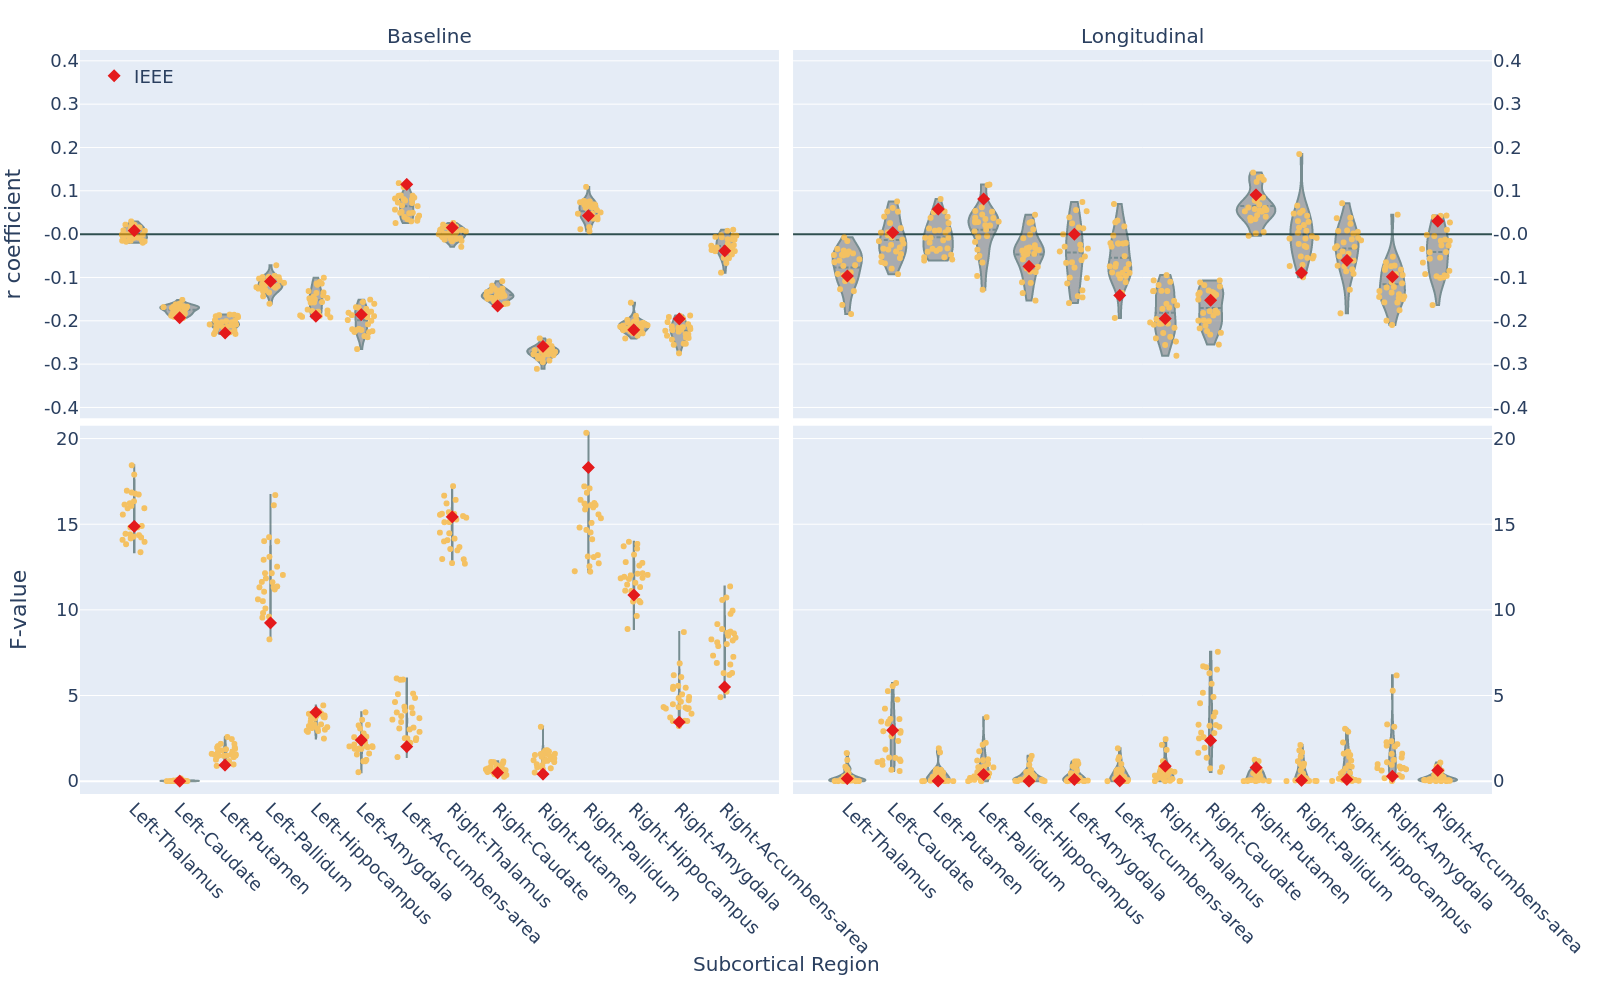

In [8]:
from plotly.subplots import make_subplots

# Create subplots with 2 rows and 2 columns
fig = make_subplots(
    rows=2,
    cols=2,
    shared_xaxes=True,
    # shared_yaxes='rows',
    column_titles=["Baseline", "Longitudinal"],
    # row_titles=["Partial Correlation", "ANCOVA"],
    x_title="Subcortical Region",
    vertical_spacing=0.01,
    horizontal_spacing=0.01,
)

# increase font
fig.update_layout(font=dict(size=18))


# Add traces to the subplots
add_pcorr_baseline_trace(fig, get_pcorr_baseline())
add_pcorr_longitudinal_trace(fig, get_pcorr_long())
add_ancova_baseline_trace(fig, get_ancova_baseline())
add_ancova_longitudinal_trace(fig, get_ancova_long())

# Set x-axis ticks and labels
fig.update_xaxes(
    title_text="", tickvals=list(range(len(regions))), ticktext=regions, tickangle=45
)

yaxis_r_range = [-0.425, 0.425]
yaxis_r_tickvals = np.arange(-0.5, 0.6, 0.1)
yaxis_r_ticktext = [str(round(x, 1)) for x in yaxis_r_tickvals]
yaxis_r_clear = ["" for x in yaxis_r_tickvals]

yaxis_f_range = [-0.75, 20.75]
yaxis_f_tickvals = [0, 10, 20, 30, 40, 50]
yaxis_f_ticktext = ["0", "10", "20", "30", "40", "50"]
yaxis_f_clear = ["" for x in yaxis_f_tickvals]

# Update layout for all axes
fig.update_layout(
    # Primary y-axes (left side, 0 to 1)
    yaxis1=dict(
        title="r coefficient",
        range=yaxis_r_range,
        dtick=0.1,
        showgrid=True,
        # dashed bold the 0 line
        zeroline=True,
        zerolinewidth=2,
        zerolinecolor="DarkSlateGrey",
        tickvals=yaxis_r_tickvals,
        ticktext=yaxis_r_ticktext,
    ),
    yaxis2=dict(
        dtick=0.1,
        showgrid=True,
        range=yaxis_r_range,
        zeroline=True,
        zerolinewidth=2,
        zerolinecolor="DarkSlateGrey",
        tickvals=yaxis_r_tickvals,
        ticktext=yaxis_r_ticktext,
        side="right",
    ),
    yaxis3=dict(
        title="F-value",
        range=yaxis_f_range,
        showgrid=True,
    ),
    yaxis4=dict(showgrid=True, range=yaxis_f_range, side="right"),
    # Other layout settings
    legend=dict(
        x=0.01,
        y=0.99,
        orientation="h",
        yanchor="top",
        xanchor="left",
        bgcolor="rgba(255, 255, 255, 0)",
    ),
    margin=dict(t=50, b=150, r=20),
    # margin=dict(b=150,
    #             l=150)  # Add bottom margin for tilted labels
)

# Increase font size
fig.update_layout(
    font=dict(size=18),
)

annotations = fig.layout.annotations
for i in range(len(annotations)):
    annotations[i].font.size = 20


for annotation in annotations:
    if annotation.text == "Subcortical Region":
        annotation.update(y=-0.17)

fig.update_layout(height=1000, width=1600)
plotly.io.write_image(fig, "statstest_coefficients_distribution.pdf")
show_figure(fig)